In [1]:
# Cell 0: read MBTA CSV
from pathlib import Path
import pandas as pd

path = Path("MBTA_Bus_Ridership_by_Trip_Season_Route_Line_and_Stop_Fall_2024.csv")
if not path.exists():
    raise FileNotFoundError(f"File not found: {path.resolve()}")

df = pd.read_csv(path, low_memory=False)
print(f"Loaded {len(df):,} rows and {len(df.columns):,} columns")
df.head()

Loaded 774,426 rows and 18 columns


,mode,season,year,route_id,route_variant,direction_id,day_type_id,day_type_name,trip_start_time,time_period_id,time_period_name,stop_name,stop_id,stop_sequence,boardings,alightings,load,sample_count
0,3,Fall,2024,1,1-_-0,0,day_type_01,weekday,4:37:00,time_period_01,VERY_EARLY_MORNING,NUBIAN STATION,64,0,13.8,0.0,13.8,69
1,3,Fall,2024,1,1-_-0,0,day_type_01,weekday,4:37:00,time_period_01,VERY_EARLY_MORNING,WASHINGTON ST OPP RUGGLES ST,1,1,0.2,0.0,14.0,69
2,3,Fall,2024,1,1-_-0,0,day_type_01,weekday,4:37:00,time_period_01,VERY_EARLY_MORNING,WASHINGTON ST @ MELNEA CASS B,2,2,0.0,0.1,14.3,69
3,3,Fall,2024,1,1-_-0,0,day_type_01,weekday,4:37:00,time_period_01,VERY_EARLY_MORNING,MELNEA CASS BLVD @ HARRISON A,6,3,0.0,0.0,14.3,69
4,3,Fall,2024,1,1-_-0,0,day_type_01,weekday,4:37:00,time_period_01,VERY_EARLY_MORNING,ALBANY ST OPP RANDALL ST,10003,4,0.1,0.0,14.4,69


In [2]:
# aggregate boardings by route_id and day_type_name
agg_boardings = (
    df.groupby(['route_id', 'day_type_name'], as_index=False)['boardings']
      .sum()
      .rename(columns={'boardings': 'total_boardings'})
)

# sort for easier inspection (highest totals first)
agg_boardings = agg_boardings.sort_values(['route_id', 'total_boardings'], ascending=[True, False])


In [3]:
agg_boardings = agg_boardings[agg_boardings['day_type_name'] == 'weekday']

In [4]:
# agg_boardings[['route_id', 'total_boardings']]
# agg_boardings.to_csv("bus_route_weekday_boardings_aggregate.csv", index=False)

In [5]:
# split out Silver Line routes from agg_boardings
silver_ids = ['741', '742', '743', '751', '749', '746']

agg_boarding_silver_line_bus = agg_boardings[agg_boardings['route_id'].isin(silver_ids)].copy()
agg_boarding_bus = agg_boardings[~agg_boardings['route_id'].isin(silver_ids)].copy()

# quick sanity/info
print("Silver-line route_ids:", silver_ids)
print(f"agg_boarding_silver_line_bus: {len(agg_boarding_silver_line_bus)} rows, total_boardings = {agg_boarding_silver_line_bus['total_boardings'].sum():,.1f}")
print(f"agg_boarding_bus: {len(agg_boarding_bus)} rows, total_boardings = {agg_boarding_bus['total_boardings'].sum():,.1f}")
print(f"Original agg_boardings: {len(agg_boardings)} rows, total_boardings = {agg_boardings['total_boardings'].sum():,.1f}")

# sanity checks
assert len(agg_boardings) == len(agg_boarding_bus) + len(agg_boarding_silver_line_bus)
assert abs(agg_boardings['total_boardings'].sum() - (agg_boarding_bus['total_boardings'].sum() + agg_boarding_silver_line_bus['total_boardings'].sum())) < 1e-6

Silver-line route_ids: ['741', '742', '743', '751', '749', '746']
agg_boarding_silver_line_bus: 6 rows, total_boardings = 32,199.8
agg_boarding_bus: 143 rows, total_boardings = 291,967.5
Original agg_boardings: 149 rows, total_boardings = 324,167.3


In [6]:
# Scale total_boardings so that their sum matches 332671
# bus_boardings_sum = 324167
bus_boardings_sum = agg_boarding_bus['total_boardings'].sum()

bus_target_sum = 299374
bus_scale_factor = bus_target_sum / bus_boardings_sum

agg_bus_boardings_scaled = agg_boarding_bus.copy()
agg_bus_boardings_scaled['total_boardings'] = agg_bus_boardings_scaled['total_boardings'] * bus_scale_factor

print(f"Scaled sum: {agg_bus_boardings_scaled['total_boardings'].sum():,.1f}")
agg_bus_boardings_scaled.head()

Scaled sum: 299,374.0


,route_id,day_type_name,total_boardings
2,1,weekday,9488.546229
5,10,weekday,2430.018555
8,100,weekday,667.104128
11,101,weekday,2735.578085
14,104,weekday,4277.833416


In [7]:
agg_bus_boardings_scaled.to_csv("agg_bus_boardings_scaled.csv", index=False)


In [8]:
# Scale total_boardings so that their sum matches 33236
# sl_boardings_sum = 324167
sl_boardings_sum = agg_boarding_silver_line_bus['total_boardings'].sum()
sl_target_sum = 33236
sl_scale_factor = sl_target_sum / sl_boardings_sum

agg_sl_boardings_scaled = agg_boarding_silver_line_bus.copy()
agg_sl_boardings_scaled['total_boardings'] = agg_sl_boardings_scaled['total_boardings'] * sl_scale_factor

print(f"Scaled sum: {agg_sl_boardings_scaled['total_boardings'].sum():,.1f}")
agg_sl_boardings_scaled.head()

Scaled sum: 33,236.0


,route_id,day_type_name,total_boardings
295,741,weekday,6310.440847
298,742,weekday,3500.949223
301,743,weekday,9568.621259
304,746,weekday,904.602836
308,749,weekday,8333.101411


In [9]:
agg_sl_boardings_scaled.to_csv("agg_sl_boardings_scaled.csv", index=False)


count        149.000000
sum       324167.300000
mean        2175.619463
median      1152.400000
std         2553.500377
min           19.400000
max        12500.100000
dtype: float64

Top 10 routes by weekday total_boardings:
    route_id  total_boardings
108       66          12500.1
51        28          11911.4
43        23          11385.6
11       111           9849.4
122      743           9270.3
0          1           9253.8
66        39           8884.3
101       57           8511.0
125      749           8073.3
38        22           7843.9

Bottom 10 routes by weekday total_boardings:
    route_id  total_boardings
99       556            115.9
98       554            113.0
49       245            106.2
74       428            105.7
100      558            105.2
80       439             80.9
96        55             77.8
86       451             47.8
61       351             24.2
27       171             19.4


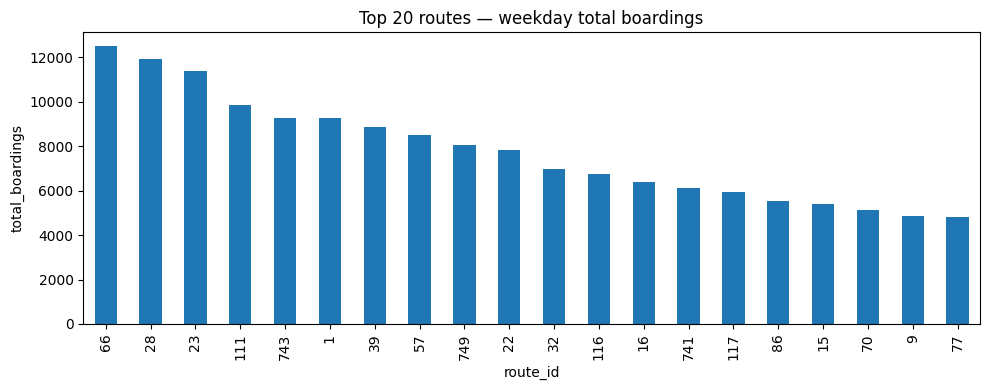

In [10]:
# aggregate statistics on agg_boardings.total_boardings (weekday)
tb = agg_boardings['total_boardings']

agg_stats = pd.Series({
    'count': tb.count(),
    'sum': tb.sum(),
    'mean': tb.mean(),
    'median': tb.median(),
    'std': tb.std(),
    'min': tb.min(),
    'max': tb.max()
})
print(agg_stats)

# re-aggregate by route_id (defensive) and sort
per_route = agg_boardings.groupby('route_id', as_index=False)['total_boardings'].sum()
per_route = per_route.sort_values('total_boardings', ascending=False)

# top / bottom routes
print("\nTop 10 routes by weekday total_boardings:")
print(per_route.head(10))

print("\nBottom 10 routes by weekday total_boardings:")
print(per_route.tail(10))

# add percent and cumulative share, save results
per_route['pct_share'] = per_route['total_boardings'] / per_route['total_boardings'].sum()
per_route['cum_share'] = per_route['pct_share'].cumsum()
per_route.to_csv("weekday_boardings_per_route_with_shares.csv", index=False)

# quick bar plot of top 20 routes (requires matplotlib)
try:
    import matplotlib.pyplot as plt
    per_route.set_index('route_id')['total_boardings'].head(20).plot(
        kind='bar', figsize=(10,4), title='Top 20 routes — weekday total boardings'
    )
    plt.ylabel('total_boardings')
    plt.tight_layout()
except Exception:
    pass